# Lilium Tower

## Parametrization and Channel Generation

In [1]:
import sys; sys.path.append('.')
import inflation, sparse_matrices, mesh, numpy as np, importlib, pickle, wall_generation
import inflatables_parametrization as parametrization
from numpy.linalg import norm
from io_redirection import suppress_stdout
import visualization, wall_width_formulas as wwf

In [2]:
sys.path.append('periodic_patches/')

In [3]:
from periodic_simulation_setup import *

In [4]:
from py_newton_optimizer import NewtonOptimizerOptions

In [5]:
import MeshFEM, parallelism, benchmark, utils
parallelism.set_max_num_tbb_threads(32)
parallelism.set_gradient_assembly_num_threads(32)
parallelism.set_hessian_assembly_num_threads(32)

In [6]:
# # Choose reasonable stretching bounds
# alphaMin = wwf.stretchFactorForCanonicalWallWidth(wwf.canonicalWallWidthForGeometry(2, 10))
# alphaMax = wwf.stretchFactorForCanonicalWallWidth(wwf.canonicalWallWidthForGeometry(1, 10))
# print(alphaMin, alphaMax)

In [7]:
# lilium = mesh.Mesh("../examples/igloo.obj")
lilium = mesh.Mesh("../examples/lilium.msh")

lg = parametrization.LocalGlobalGenericParametrizer(lilium, parametrization.lscm(lilium))
# lg = parametrization.LocalGlobalParametrizer(lilium, parametrization.lscm(lilium))

print(lg.energy())
for i in range(1000): lg.runIteration()
# # print(lg.energy())
lg.alphaMin = 1.0
lg.alphaMax = 1.3 #np.pi / 2

lg.betaMin = 1.0
lg.betaMax = 1.3 #np.pi / 2

print(lg.energy())
lg.runIteration()
print(lg.energy())

# rparam = parametrization.RegularizedGenericParametrizer(lg)
for i in range(5000): lg.runIteration()
print(lg.energy())

0.09689440378098683
0.006800117173616746
0.002486194705574862
3.8344596378755857e-28


In [8]:
lg.energy()


3.8344596378755857e-28

In [9]:
#rparam = parametrization.RegularizedParametrizerSVD(lilium, np.loadtxt('data/lilium_tower_parametrization_4_10_2019.txt'))
# rparam = parametrization.RegularizedParametrizerSVD(lg)

rparam = parametrization.RegularizedGenericParametrizer(lg)
rparam.useBarrier = True
# rparam.alphaMin = 1.0
# rparam.alphaMax = 1.4 #np.pi / 2

# rparam.betaMin = 1.0
# rparam.betaMax = 1.4 #np.pi / 2

# rparam = parametrization.RegularizedParametrizer(lg)
# rparam = parametrization.RegularizedParametrizer(lg)
# rparam.alphaMin = alphaMin
# rparam.alphaMax = alphaMax

In [10]:
PET = parametrization.RegularizedGenericParametrizer.EnergyType
list(map(rparam.energy, [PET.Fitting, PET.StretchRegularization, PET.PhiRegularization, PET.DiffRegularization]))

[3.7245738376388715e-28,
 0.9099039413489236,
 11.07496565760092,
 19336.497729710274]

In [11]:
rparam.stretchRegP, rparam.phiRegP

(2.0, 2.0)

In [12]:
def optimize_rparam(param, alphaRegW, phiRegW, diffRegW = 0):
    param.stretchRegW = alphaRegW
    # param.alphaRegW = alphaRegW    
    param.phiRegW = phiRegW
    param.diffRegW = diffRegW
    opts = NewtonOptimizerOptions()
    opts.useIdentityMetric = True
    opts.beta = 1e-4
    opts.niter = 800
    opts.gradTol = 1e-9
    opts.factorizer = opts.factorizer.CatamariNesdis
    # opts.verboseWorkingSet = True
    # opts.verbose = False
    benchmark.reset()
    # cr = parametrization.regularized_parametrization_knitro(param, 1000, [param.uOffset(), param.vOffset(), param.phiOffset()])
    cr = parametrization.regularized_parametrization_newton(param, [param.uOffset(), param.vOffset(), param.phiOffset()], opts)
    # cr = parametrization.regularized_parametrization_newton(param, param.rigidMotionPinVars, opts)
    benchmark.report()
    return cr

In [13]:
rparam.getAlphas().min(),rparam.getAlphas().max(), rparam.getBetas().min(),rparam.getBetas().max() 

(1.0003547630661125, 1.3, 1.0, 1.0929159049247406)

0.0001691828243075566 0.30000000000000004


(array([ 968., 1355., 1070.,  993.,  814.,  740.,  372.,  134.,  104.,
          40.]),
 array([1.69182824e-04, 3.01522645e-02, 6.01353463e-02, 9.01184280e-02,
        1.20101510e-01, 1.50084591e-01, 1.80067673e-01, 2.10050755e-01,
        2.40033837e-01, 2.70016918e-01, 3.00000000e-01]),
 <BarContainer object of 10 artists>)

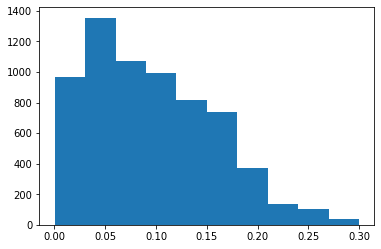

In [14]:
import matplotlib.pyplot as plt
diff = rparam.getAlphas() - rparam.getBetas()
print(diff.min(), diff.max())
plt.hist(diff)



In [15]:
b = rparam.getBarriers()
b.min(), b.max()

(0.18181895598934456, 0.9760598516618672)

In [16]:
# with suppress_stdout(): report = optimize_rparam(rparam, 2e-3, 2e-2, 1e-9)
# with suppress_stdout(): report = optimize_rparam(rparam, 1e-4, 3e-5, 1e-10)
# with suppress_stdout(): report = optimize_rparam(rparam, 1e-5, 1e-5, 1e-10)

with suppress_stdout(): report = optimize_rparam(rparam, 2e-3, 2e-3, 0)
with suppress_stdout(): report = optimize_rparam(rparam, 1e-4, 1e-5, 0)
with suppress_stdout(): report = optimize_rparam(rparam, 1e-5, 1e-6, 0)


In [45]:
# with suppress_stdout(): report = optimize_rparam(rparam, 2e-3, 2e-3, 0)
# with suppress_stdout(): report = optimize_rparam(rparam, 1e-4, 3e-5, 0)
# with suppress_stdout(): report = optimize_rparam(rparam, 1e-5, 1e-5, 0)
# # with suppress_stdout(): report = optimize_rparam(rparam, 1e-4, 3e-4, 0)
# # with suppress_stdout(): report = optimize_rparam(rparam, 1e-5, 1e-4, 0)



0.18181818181818182 0.9760598516618672


(array([1601., 1147.,  909.,  744.,  492.,  423.,  391.,  306.,  216.,
         361.]),
 array([0.18181818, 0.26124235, 0.34066652, 0.42009068, 0.49951485,
        0.57893902, 0.65836318, 0.73778735, 0.81721152, 0.89663568,
        0.97605985]),
 <BarContainer object of 10 artists>)

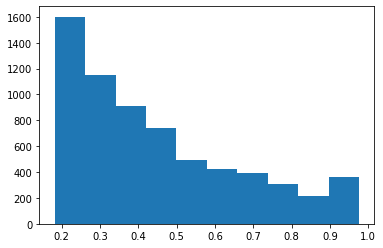

In [17]:
b = rparam.getBarriers()
print(b.min(), b.max())
plt.hist(b)

In [18]:
# with suppress_stdout(): report = optimize_rparam(rparam, 1e-5, 1e-3)
# import matplotlib.pyplot as plt
# plt.hist(rparam.getAlphas() - rparam.getBetas())

In [19]:
PET = parametrization.RegularizedGenericParametrizer.EnergyType
list(map(rparam.energy, [PET.Fitting, PET.StretchRegularization, PET.PhiRegularization, PET.DiffRegularization]))

[4.3491587969137234e-07, 5.519994037573801e-06, 3.262716725763026e-06, 0.0]

In [21]:
PET = parametrization.RegularizedGenericParametrizer.EnergyType
list(map(rparam.energy, [PET.Fitting, PET.StretchRegularization, PET.PhiRegularization]))

[1.9459594418050305e-07, 3.7117654971518864e-06, 5.9948541215698775e-09]

In [22]:
PET = parametrization.RegularizedGenericParametrizer.EnergyType
list(map(rparam.energy, [PET.Fitting, PET.StretchRegularization, PET.PhiRegularization]))

[1.9459594418050305e-07, 3.7117654971518864e-06, 5.9948541215698775e-09]

In [23]:
# # # Run this a cycle 3 times for convergence
# with suppress_stdout(): report = optimize_rparam(rparam, 0, 2e-3)
# with suppress_stdout(): report = optimize_rparam(rparam, 0, 3e-5)
# with suppress_stdout(): report = optimize_rparam(rparam, 0, 1e-5)


In [24]:
# # # Run this a cycle 3 times for convergence
# with suppress_stdout(): report = optimize_rparam(rparam, 0, 0)
# with suppress_stdout(): report = optimize_rparam(rparam, 0, 0)
# with suppress_stdout(): report = optimize_rparam(rparam, 0, 0)

In [20]:
report.success


False

In [21]:
rparam.alphaMin, rparam.alphaMax, rparam.getAlphas().min(), rparam.getAlphas().max()

(1.0, 1.3, 1.0, 1.3)

In [22]:
# diff = abs(rparam.getAlphas() - rparam.getBetas())
# indices = np.where((diff < 1e-3) * (diff > -1e-3))[0]
# m = rparam.mesh().copy()
# vertices = np.zeros(m.vertices().shape)
# vertices[:,:2] = rparam.uv()
# m.setVertices(vertices)
# m.barycenters()[indices][:,:2]

In [23]:
rparam.betaMin, rparam.betaMax, rparam.getBetas().min(), rparam.getBetas().max()

(1.0, 1.3, 1.0, 1.0914230758158456)

(array([ 463., 1105., 1523., 1380.,  830.,  561.,  287.,  162.,  145.,
         134.]),
 array([-0.00804702,  0.02275768,  0.05356238,  0.08436708,  0.11517179,
         0.14597649,  0.17678119,  0.20758589,  0.2383906 ,  0.2691953 ,
         0.3       ]),
 <BarContainer object of 10 artists>)

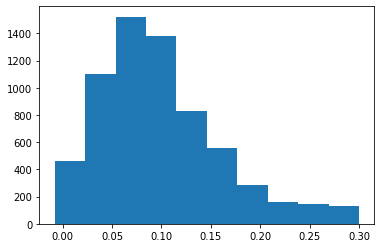

In [24]:
import matplotlib.pyplot as plt
plt.hist(rparam.getAlphas() - rparam.getBetas())

(array([ 463., 1105., 1523., 1380.,  830.,  561.,  287.,  162.,  145.,
         134.]),
 array([-0.00804702,  0.02275768,  0.05356238,  0.08436708,  0.11517179,
         0.14597649,  0.17678119,  0.20758589,  0.2383906 ,  0.2691953 ,
         0.3       ]),
 <BarContainer object of 10 artists>)

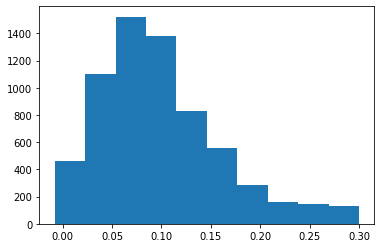

In [25]:
import matplotlib.pyplot as plt
plt.hist(rparam.getAlphas() - rparam.getBetas())

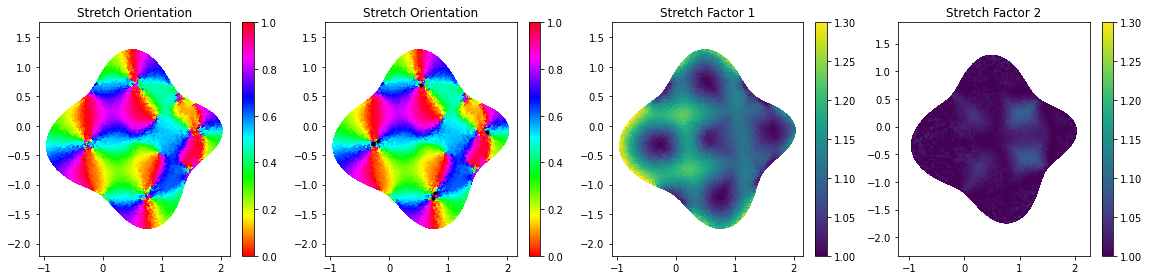

In [26]:
visualization.visualize_both(lg, height = 4)

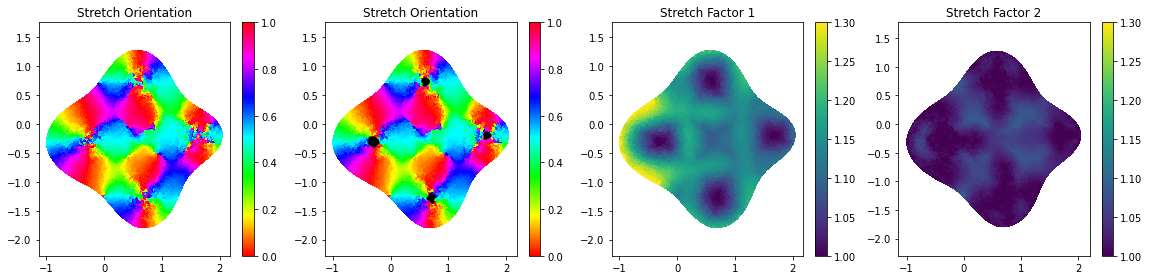

In [27]:
import importlib
importlib.reload(visualization)
visualization.visualize_both(rparam, height = 4)

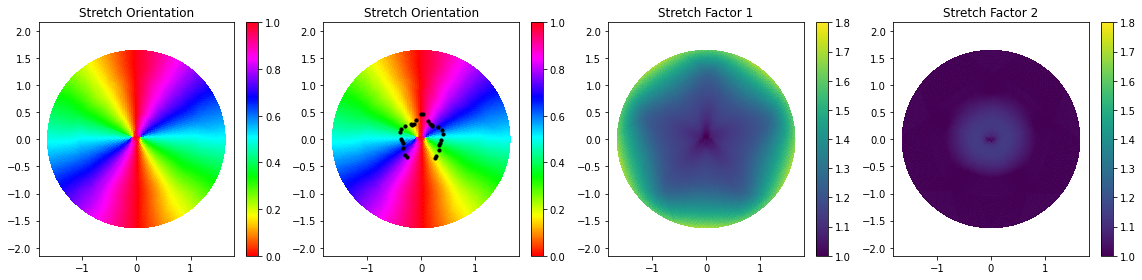

In [35]:
import importlib
importlib.reload(visualization)
visualization.visualize_both(rparam, height=4)

In [36]:
assert 0

AssertionError: 

In [ ]:
importlib.reload(visualization)
visualization.visualizeChannelOrientation(rparam, quiver=visualization.QuiverVisualization.PER_VTX, orientationHue=False)


In [ ]:
# visualization.singularValueHistogramBoth(rparam)

In [ ]:
widths = wwf.wallWidthForCanonicalWidth(wwf.canonicalWallWidthForStretchFactor(rparam.getAlphas()), 10)
(np.min(widths), np.max(widths))

## Upsampling and channel generation

In [ ]:
nsubdiv=4
upsampledMesh, upsampledAngles, upsampledStretches = rparam.upsampledVertexLeftStretchAnglesAndMagnitudes(nsubdiv)
(sdfVertices, sdfTris, sdf) = wall_generation.evaluate_stripe_field(upsampledMesh.vertices(), upsampledMesh.triangles(), upsampledAngles,
                                                                    wwf.canonicalWallWidthForStretchFactor(upsampledStretches), frequency=100)
pickle.dump((sdfVertices, sdfTris, sdf), open('stripe_sdf_ns4_f100.pkl', 'wb'))

In [ ]:
rparam.getBetas()

In [ ]:
upsampledAngles.shape, upsampledStretches.shape

In [ ]:
upsampledMesh.vertices().shape

In [ ]:
import pickle, mesh, wall_generation, visualization, numpy as np
(sdfVertices, sdfTris, sdf) = pickle.load(open('stripe_sdf_ns4_f100.pkl', 'rb'))

In [ ]:
visualization.scalarFieldPlotFast(sdfVertices, sdfTris, sdf, height=12)

In [ ]:
pts, edges = wall_generation.extract_contours(sdfVertices, sdfTris, sdf,
                                              targetEdgeSpacing=0.01,
                                              minContourLen=0.075)

In [ ]:
visualization.plot_line_segments(pts, edges, width=20, height=16)


## Meshing and inflation simulation

In [ ]:
m, fuseMarkers, fuseSegments = wall_generation.triangulate_channel_walls(pts[:,0:2], edges, 0.0002)
visualization.plot_2d_mesh(m, pointList=np.where(np.array(fuseMarkers) == 1)[0], width=20, height=18)

In [ ]:
import inflation
isheet = inflation.InflatableSheet(m, np.array(fuseMarkers) != 0)

In [ ]:
from mesh_utilities import SurfaceSampler, tubeRemesh


In [ ]:
paramSampler = SurfaceSampler(np.pad(rparam.uv(), [(0, 0), (0, 1)], 'constant'), lilium.triangles())
liftedSheetPositions = paramSampler.sample(m.vertices(), lilium.vertices())

In [ ]:
isheet.setUninflatedDeformation(liftedSheetPositions.transpose())

In [ ]:
import py_newton_optimizer
niter = 2000
iterations_per_output = 10
opts = py_newton_optimizer.NewtonOptimizerOptions()
opts.useIdentityMetric = True
opts.beta = 1e-4
opts.gradTol = 1e-10
opts.niter = iterations_per_output

In [ ]:
# Are the flat region causing a problem? They might not actually control the metric...
# Try replacing them with single wall...
# Analyze the actual stretching factor (much easier to do with skeleton walls)

In [ ]:
from tri_mesh_viewer import TriMeshViewer
viewer = TriMeshViewer(isheet.visualizationMesh(), width=768, height=640)
viewer.showWireframe()
viewer.show()

In [ ]:
isheet.setUseTensionFieldEnergy(True)

In [ ]:
mkdir lilium_inflate_freq100

In [ ]:
fixedVars, hessianShift = [], 1e-6


In [ ]:
import time
isheet.pressure = 35
benchmark.reset()
for step in range(int(niter / iterations_per_output)):
    cr = inflation.inflation_newton(isheet, fixedVars, opts, hessianShift = hessianShift)
    if cr.numIters() < iterations_per_output: break
    isheet.writeDebugMesh('lilium_inflate_freq100/inflation_tf_lifted_step_{}.msh'.format(step))
    viewer.update(False, isheet.visualizationMesh())
    time.sleep(0.05) # Allow some mesh synchronization time for pythreejs
benchmark.report()

In [ ]:
isheet.tensionStateHistogram()